## Stage 0: Scaffold

Repository layout, pinned requirements, README skeleton, and smoke tests.

## Stage 1a: History (SPY, VIX, IRX)

Download and freeze SPY, ^VIX, and ^IRX daily closes with a manifest.

## Stage 1b: Chain collection

Run the chain collector on 3 to 5 market days and freeze the snapshot.

## Stage 2a: Black-Scholes pricing and Greeks

Implement Black-76 pricing and spot Greeks; verify against DESIGN.md acceptance values.

## Stage 5a: Hedging engine

Implement the delta-hedging simulation and verify on synthetic GBM paths.

## Stage 5b: Real-data hedging study

Run the hedging study on real SPY paths; produce Figures 6 to 8 and Table 4.

The study delta-hedges a 30-day at-the-money call bought at the VIX on every trading day, following DESIGN.md section 3. It reads only the frozen history, so it reruns without a download. P&L and predictors are fractions of the premium carried to expiry (C0·G0), shown in percent.

In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FixedLocator, NullLocator, ScalarFormatter

from volsurf import hedging as hg
from volsurf.black_scholes import bs_vega
from volsurf.data import load_history

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
FIGURES = ROOT / "figures"

H_VALUES = [1, 2, 3, 5, 7, 10, 21]  # rebalance interval in trading days
C_BP = [0, 1, 5, 25, 100]  # cost in bp of notional traded
PREDICTORS = ["P_gap", "P_path", "P_step"]
BLOCK, N_RESAMPLES, SEED_BOOT = 42, 2000, 20260930  # moving block bootstrap
N_PATHS, SEED_GBM = 100, 20261001  # GBM paths per real window; windows of n steps use seed [SEED_GBM, n]
SEEDS_TEXTBOOK = [(20261100 + k, 20261200 + k) for k in range(40)]  # section 3 set, 40 seed pairs
APRIL_2025 = ("2025-04-03", "2025-04-09")
N_OFFSETS = 21  # starting windows of the non-overlapping subsamples

# Chart style: recessive grid and axes, ink for text, series colours for marks only.
INK, INK_2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
COST_COLOURS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]  # one blue, light to dark with cost
COST_MARKERS = ["o", "s", "^", "D", "v"]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "font.size": 9, "axes.titlesize": 10, "figure.titlesize": 11, "legend.frameon": False,
    "lines.linewidth": 2, "lines.markersize": 5,
})


def save(fig, name):
    """Save a figure to figures/ at 200 dpi and print its repository-relative path."""
    path = FIGURES / name
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved {path.relative_to(ROOT).as_posix()}")


def predictors(res, rows=slice(None)):
    """The three predictors of a HedgeResult, optionally restricted to some windows."""
    return {name: getattr(res, name.lower())[rows] for name in PREDICTORS}


history = load_history()
dates = history.index
S, r = history["spy"].to_numpy(), history["r"].to_numpy()
win = hg.study_windows(history)
steps = win.ends - win.starts
start_dates = dates[win.starts]
print(f"History: {dates[0].date()} to {dates[-1].date()}, {dates.size} closes")
print(
    f"Windows: {win.starts.size}, starting {start_dates[0].date()} to {start_dates[-1].date()}; "
    f"{steps.min()} to {steps.max()} trading-day steps; T0 from {win.T0.min() * 365:.0f} "
    f"to {win.T0.max() * 365:.0f} calendar days"
)

History: 2021-06-01 to 2026-09-29, 1339 closes
Windows: 1232, starting 2021-10-01 to 2026-08-28; 17 to 22 trading-day steps; T0 from 27 to 30 calendar days


In [2]:
results = {
    (h, c): hg.simulate_windows(S, win.t, r, win.starts, win.ends, win.sigma_i, win.K, h, c * 1e-4)
    for h in H_VALUES
    for c in C_BP
}
base = results[(1, 0)]  # daily hedging, no costs
n_by_h = {h: results[(h, 0)].n_intervals for h in H_VALUES}
print("Hedge intervals N per window: mean (min to max)")
for h in H_VALUES:
    print(f"  h = {h:>2}: {n_by_h[h].mean():5.2f} ({n_by_h[h].min()} to {n_by_h[h].max()})")

Hedge intervals N per window: mean (min to max)
  h =  1: 20.58 (17 to 22)
  h =  2: 10.55 (9 to 11)
  h =  3:  7.17 (6 to 8)
  h =  5:  4.58 (4 to 5)
  h =  7:  3.20 (3 to 4)
  h = 10:  2.58 (2 to 3)
  h = 21:  1.20 (1 to 2)


## Figure 7: implied against realised volatility
VIX at each window start against the realised volatility of that window, sigma_r = √(RV/T0), where RV sums squared daily log returns. The share of windows whose implied total variance exceeds the realised one does not depend on h or c, so it is reported once.

Share of windows with sigma_i^2*T0 > RV: 84.3% of 1232
Mean sigma_i (VIX): 19.18%; mean realised vol sigma_r: 15.78%
Mean total variance over a window: implied 0.00319, realised 0.00246


Saved figures/fig7_vix_vs_realised_vol.png


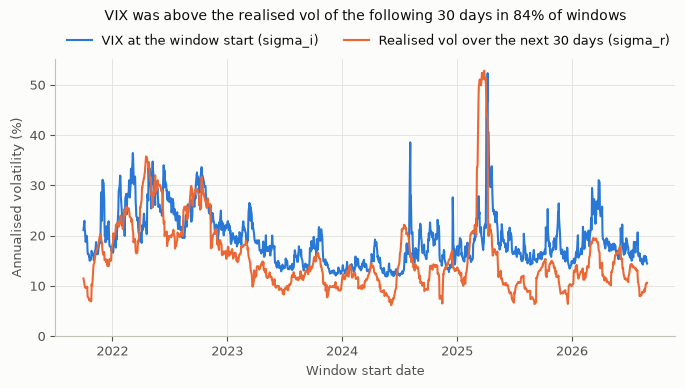

In [3]:
implied_var, rv = win.sigma_i**2 * win.T0, base.rv
sigma_r = np.sqrt(rv / win.T0)
share_implied_above = np.mean(implied_var > rv)
print(f"Share of windows with sigma_i^2*T0 > RV: {share_implied_above:.1%} of {rv.size}")
print(f"Mean sigma_i (VIX): {win.sigma_i.mean():.2%}; mean realised vol sigma_r: {sigma_r.mean():.2%}")
print(f"Mean total variance over a window: implied {implied_var.mean():.5f}, realised {rv.mean():.5f}")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(start_dates, 100 * win.sigma_i, color=BLUE, lw=1.5, label="VIX at the window start (sigma_i)")
ax.plot(start_dates, 100 * sigma_r, color=ORANGE, lw=1.5, label="Realised vol over the next 30 days (sigma_r)")
ax.set_xlabel("Window start date")
ax.set_ylabel("Annualised volatility (%)")
ax.set_ylim(bottom=0)
ax.set_title(
    f"VIX was above the realised vol of the following 30 days in {share_implied_above:.0%} of windows",
    pad=28,
)
ax.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncol=2)
save(fig, "fig7_vix_vs_realised_vol.png")
plt.show()

## Table 4b: the R² ladder at c = 0
R²_45 is measured about the 45 degree line and the slope comes from OLS of P&L on each predictor. Intervals are 95% moving block bootstrap percentiles over windows in start-date order. The GBM benchmark hedges 100 GBM paths on each real window's calendar and rates, with sigma_true set to that window's realised vol and sigma_i to its VIX, and pools every path. The April 2025 rows drop every window with a close from 2025-04-03 to 2025-04-09 and resample the remaining sequence.

In [4]:
april = hg.windows_containing(dates, win.starts, win.ends, *APRIL_2025)
keep = ~april
boot_full = hg.block_bootstrap_indices(win.starts.size, BLOCK, N_RESAMPLES, SEED_BOOT)
boot_keep = hg.block_bootstrap_indices(int(keep.sum()), BLOCK, N_RESAMPLES, SEED_BOOT)
print(
    f"April 2025 exclusion: {april.sum()} windows removed (starts {start_dates[april][0].date()} "
    f"to {start_dates[april][-1].date()}), {keep.sum()} kept"
)

gbm_benchmark = {
    h: hg.simulate_gbm_windows(win.t, r, win.starts, win.ends, sigma_r, win.sigma_i, h, 0.0, N_PATHS, SEED_GBM)
    for h in H_VALUES
}
ladders = {}
for h in H_VALUES:
    res, bench = results[(h, 0)], gbm_benchmark[h]
    ladders[("Full sample", h)] = hg.r2_ladder(res.pnl, predictors(res), boot_full)
    ladders[("GBM benchmark", h)] = hg.r2_ladder(
        bench.pnl.ravel(), {k: v.ravel() for k, v in predictors(bench).items()}
    )
    ladders[("Excluding April 2025", h)] = hg.r2_ladder(res.pnl[keep], predictors(res, keep), boot_keep)
table_4b = pd.concat(ladders, names=["sample", "h", "predictor"])
with pd.option_context("display.max_rows", 100, "display.float_format", "{:.3f}".format):
    display(table_4b)

April 2025 exclusion: 27 windows removed (starts 2025-03-04 to 2025-04-09), 1205 kept


n  r2_45  r2_lo  r2_hi  alpha  beta  \
sample               h  predictor                                             
Full sample          1  P_gap        1232 -0.199 -1.124  0.643 -0.118 0.473   
                        P_path       1232  0.671  0.472  0.847 -0.056 0.715   
                        P_step       1232  0.941  0.919  0.956 -0.013 0.961   
GBM benchmark        1  P_gap      123200  0.572    NaN    NaN -0.094 0.718   
                        P_path     123200  0.923    NaN    NaN  0.013 1.028   
                        P_step     123200  0.963    NaN    NaN -0.006 0.992   
Excluding April 2025 1  P_gap        1205  0.592  0.512  0.665 -0.058 0.818   
                        P_path       1205  0.830  0.788  0.858 -0.005 0.949   
                        P_step       1205  0.942  0.914  0.959 -0.003 1.002   
Full sample          2  P_gap        1232 -0.066 -0.701  0.481 -0.111 0.491   
                        P_path       1232  0.462  0.254  0.647 -0.057 0.690   
                        P_step       1232  0.800  0.629  0.931 -0.041 0.821   
GBM benchmark        2  P_gap      123200  0.484    NaN    NaN -0.094 0.713   
                        P_path     123200  0.768    NaN    NaN  0.006 1.007   
                        P_step     123200  0.931    NaN    NaN -0.011 0.981   
Excluding April 2025 2  P_gap        1205  0.413  0.294  0.500 -0.054 0.818   
                        P_path       1205  0.597  0.493  0.668  0.003 0.969   
                        P_step       1205  0.905  0.858  0.936 -0.010 0.978   
Full sample          3  P_gap        1232 -0.081 -0.668  0.395 -0.116 0.485   
                        P_path       1232  0.404  0.258  0.536 -0.063 0.688   
                        P_step       1232  0.853  0.788  0.912 -0.030 0.884   
GBM benchmark        3  P_gap      123200  0.433    NaN    NaN -0.094 0.715   
                        P_path     123200  0.656    NaN    NaN -0.001 0.989   
                        P_step     123200  0.904    NaN    NaN -0.016 0.965   
Excluding April 2025 3  P_gap        1205  0.325  0.203  0.417 -0.059 0.812   
                        P_path       1205  0.479  0.372  0.554 -0.003 0.962   
                        P_step       1205  0.889  0.846  0.917 -0.003 1.001   
Full sample          5  P_gap        1232 -0.563 -2.096  0.246 -0.149 0.333   
                        P_path       1232 -0.032 -0.734  0.356 -0.111 0.488   
                        P_step       1232  0.837  0.801  0.866 -0.006 0.988   
GBM benchmark        5  P_gap      123200  0.339    NaN    NaN -0.095 0.709   
                        P_path     123200  0.486    NaN    NaN -0.017 0.935   
                        P_step     123200  0.835    NaN    NaN -0.029 0.925   
Excluding April 2025 5  P_gap        1205  0.180  0.065  0.271 -0.079 0.729   
                        P_path       1205  0.323  0.236  0.379 -0.023 0.906   
                        P_step       1205  0.844  0.807  0.872  0.007 1.043   
Full sample          7  P_gap        1232 -0.116 -0.591  0.207 -0.130 0.459   
                        P_path       1232  0.145 -0.048  0.281 -0.091 0.606   
                        P_step       1232  0.842  0.814  0.866 -0.004 1.020   
GBM benchmark        7  P_gap      123200  0.300    NaN    NaN -0.094 0.721   
                        P_path     123200  0.379    NaN    NaN -0.032 0.889   
                        P_step     123200  0.778    NaN    NaN -0.045 0.866   
Excluding April 2025 7  P_gap        1205  0.153  0.034  0.241 -0.077 0.767   
                        P_path       1205  0.238  0.128  0.317 -0.033 0.888   
                        P_step       1205  0.846  0.818  0.870  0.027 1.150   
Full sample          10 P_gap        1232 -0.302 -1.120  0.167 -0.158 0.355   
                        P_path       1232 -0.106 -0.649  0.210 -0.137 0.435   
                        P_step       1232  0.819  0.781  0.846  0.024 1.147   
GBM benchmark        10 P_gap      123200  0.247    NaN    NaN -0.093 0.722   
           

## Table 4c: non-overlapping subsamples
Each subsample is built greedily: from a starting window, the next window is the first whose start close is at or after the previous window's end close, so no two windows share a daily return. The first 21 windows each start one subsample. The table gives the point estimates for the subsample from window 0 and the median and range across all 21.

In [5]:
subsamples = [hg.non_overlapping(win.starts, win.ends, k) for k in range(N_OFFSETS)]
sizes = [sub.size for sub in subsamples]
print(f"{N_OFFSETS} non-overlapping subsamples of {min(sizes)} to {max(sizes)} windows")
# Greedy chains can merge: once two subsamples pick the same window they coincide from there on.
distinct = np.unique(np.concatenate(subsamples))
chains = len({sub[-1] for sub in subsamples})
weekday_0 = pd.Series(start_dates[subsamples[0]].day_name()).value_counts()
print(f"Distinct windows across the {N_OFFSETS} subsamples: {distinct.size}; distinct chains at the end: {chains}")
print("Start weekdays of the window-0 subsample: " + ", ".join(f"{d} {n}" for d, n in weekday_0.items()))
rows = []
for h in H_VALUES:
    res = results[(h, 0)]
    per_start = pd.concat(
        {k: hg.r2_ladder(res.pnl[sub], predictors(res, sub)) for k, sub in enumerate(subsamples)},
        names=["start", "predictor"],
    )
    for name in PREDICTORS:
        x = per_start.xs(name, level="predictor")
        row = {"h": h, "predictor": name, "n (window 0)": int(x.loc[0, "n"])}
        for stat, label in (("r2_45", "R2_45"), ("beta", "slope")):
            row[f"{label} window 0"] = x.loc[0, stat]
            row[f"{label} median"] = x[stat].median()
            row[f"{label} min"] = x[stat].min()
            row[f"{label} max"] = x[stat].max()
        rows.append(row)
table_4c = pd.DataFrame(rows).set_index(["h", "predictor"])
with pd.option_context("display.max_rows", 100, "display.float_format", "{:.3f}".format):
    display(table_4c)

21 non-overlapping subsamples of 64 to 65 windows
Distinct windows across the 21 subsamples: 280; distinct chains at the end: 4
Start weekdays of the window-0 subsample: Friday 61, Thursday 4


n (window 0)  R2_45 window 0  R2_45 median  R2_45 min  \
h  predictor                                                          
1  P_gap                65          -0.255        -0.254     -0.725   
   P_path               65           0.010         0.611     -0.008   
   P_step               65           0.915         0.916      0.873   
2  P_gap                65          -0.597        -0.594     -0.880   
   P_path               65          -0.553         0.181     -0.636   
   P_step               65           0.793         0.795     -0.060   
3  P_gap                65          -0.720         0.005     -0.756   
   P_path               65          -0.517         0.150     -0.556   
   P_step               65           0.880         0.880      0.555   
5  P_gap                65          -0.170        -0.245     -1.386   
   P_path               65           0.102         0.011     -0.263   
   P_step               65           0.834         0.834      0.816   
7  P_gap                65          -0.270        -0.068     -0.314   
   P_path               65          -0.542         0.206     -0.603   
   P_step               65           0.849         0.849      0.761   
10 P_gap                65          -0.494        -0.564     -0.633   
   P_path               65          -0.643        -0.231     -0.735   
   P_step               65           0.799         0.808      0.787   
21 P_gap                65          -0.066        -0.098     -0.574   
   P_path               65          -0.066        -0.098     -0.574   
   P_step               65           0.811         0.808      0.794   

              R2_45 max  slope window 0  slope median  slope min  slope max  
h  predictor                                                                 
1  P_gap          0.574           0.463         0.464      0.416      0.802  
   P_path         0.907           0.503         0.662      0.499      0.862  
   P_step         0.952           0.892         0.914      0.887      1.015  
2  P_gap          0.589           0.366         0.367      0.358      0.870  
   P_path         0.767           0.383         0.553      0.373      1.020  
   P_step         0.957           0.841         0.841      0.493      0.988  
3  P_gap          0.154           0.308         0.504      0.304      0.607  
   P_path         0.573           0.355         0.593      0.349      0.787  
   P_step         0.961           1.087         0.975      0.700      1.088  
5  P_gap          0.026           0.461         0.434      0.198      0.536  
   P_path         0.103           0.558         0.518      0.375      0.566  
   P_step         0.888           0.994         0.999      0.975      1.141  
7  P_gap          0.225           0.377         0.475      0.360      0.855  
   P_path         0.344           0.317         0.639      0.303      0.865  
   P_step         0.864           1.128         1.021      0.862      1.128  
10 P_gap          0.201           0.251         0.262      0.218      0.870  
   P_path         0.249           0.226         0.371      0.195      0.935  
   P_step         0.825           1.295         1.284      1.056      1.356  
21 P_gap          0.097           0.444         0.411     -0.000      0.806  
   P_path         0.097           0.444         0.411     -0.000      0.806  
   P_step         0.817           1.398         1.486      1.387      1.533

## Figure 6: hedged P&L against the vol gap
Daily hedging without costs gives one point per window. The windows removed by the April 2025 exclusion are marked. The right panel repeats the plot for the step predictor, which weights each day's squared return by that day's gamma.

Saved figures/fig6_pnl_vs_vol_gap.png


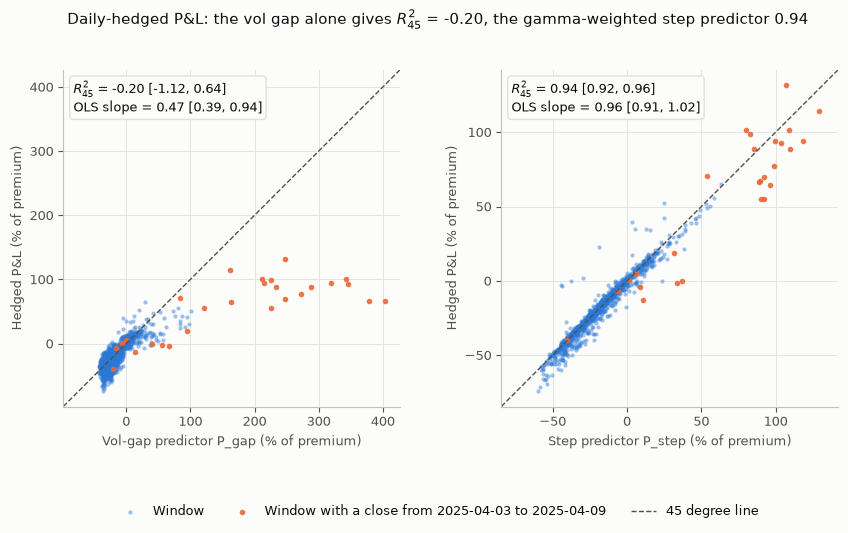

In [6]:
ladder_1 = ladders[("Full sample", 1)]
y = 100 * base.pnl
fig, axes = plt.subplots(1, 2, figsize=(10, 5.2))
for ax, name, label in zip(axes, ["P_gap", "P_step"], ["Vol-gap predictor P_gap", "Step predictor P_step"]):
    p = 100 * predictors(base)[name]
    row = ladder_1.loc[name]
    ax.scatter(p[keep], y[keep], s=9, color=BLUE, alpha=0.45, linewidths=0, label="Window")
    ax.scatter(p[april], y[april], s=16, color=ORANGE, alpha=0.9, linewidths=0,
               label="Window with a close from 2025-04-03 to 2025-04-09")
    lo, hi = min(p.min(), y.min()), max(p.max(), y.max())
    pad = 0.05 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=INK_2, lw=1, ls="--", label="45 degree line")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal")  # equal scales, so the 45 degree line reads as one
    ax.text(
        0.03, 0.97,
        f"$R^2_{{45}}$ = {row.r2_45:.2f} [{row.r2_lo:.2f}, {row.r2_hi:.2f}]\n"
        f"OLS slope = {row.beta:.2f} [{row.beta_lo:.2f}, {row.beta_hi:.2f}]",
        transform=ax.transAxes, va="top", ha="left", color=INK,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "#fcfcfb", "edgecolor": GRID},
    )
    ax.set_xlabel(f"{label} (% of premium)")
    ax.set_ylabel("Hedged P&L (% of premium)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(bottom=0.2, wspace=0.3)
fig.suptitle(
    f"Daily-hedged P&L: the vol gap alone gives $R^2_{{45}}$ = {ladder_1.loc['P_gap', 'r2_45']:.2f}, "
    f"the gamma-weighted step predictor {ladder_1.loc['P_step', 'r2_45']:.2f}"
)
save(fig, "fig6_pnl_vs_vol_gap.png")
plt.show()

## Table 4a and Figure 8: hedging error
The hedging error is e = P&L - P_gap per window, and RMSE = √(mean² + std²) with the population std. N is the number of hedge intervals, which varies with window length. Figure 8 plots each h at its mean N, with bars from the minimum to the maximum N. The synthetic reference hedges 100 GBM paths on each real window's calendar with sigma_true = sigma_i at no cost and uses each path's own realised variance in P_gap. The dashed Derman-Kamal curve is the known-vol asymptote √(π/4)·vega0·sigma_i/(√N·C0), averaged over windows.

In [7]:
rows = []
for h in H_VALUES:
    n = n_by_h[h]
    for c in C_BP:
        res = results[(h, c)]
        stats = hg.hedging_error_stats(res.pnl, res.p_gap)
        rows.append({
            "h": h, "c (bp)": c, "mean N": n.mean(), "min N": n.min(), "max N": n.max(),
            "mean P&L (%)": 100 * res.pnl.mean(), "mean e (%)": 100 * stats["mean"],
            "std e (%)": 100 * stats["std"], "RMSE e (%)": 100 * stats["rmse"],
        })
table_4a = pd.DataFrame(rows).set_index(["h", "c (bp)"])
with pd.option_context("display.max_rows", 100, "display.float_format", "{:.2f}".format):
    display(table_4a)

gbm_reference = {
    h: hg.simulate_gbm_windows(win.t, r, win.starts, win.ends, win.sigma_i, win.sigma_i, h, 0.0, N_PATHS, SEED_GBM)
    for h in H_VALUES
}
reference = pd.DataFrame(
    {h: {k: 100 * v for k, v in hg.hedging_error_stats(res.pnl, res.p_gap).items()} for h, res in gbm_reference.items()}
).T.rename_axis("h")
reference.insert(0, "mean N", [n_by_h[h].mean() for h in H_VALUES])
print("Synthetic reference (GBM on the real calendars, sigma_true = sigma_i, c = 0), % of premium:")
display(reference.round(2))
vega0 = bs_vega(S[win.starts], win.K, win.T0, r[win.starts], 0.0, win.sigma_i)
dk_scale = np.mean(vega0 * win.sigma_i / base.c0)  # Derman-Kamal curve is 100·dk_scale·√(π/4)/√N (%)
best_h = {c: table_4a.xs(c, level="c (bp)")["RMSE e (%)"].idxmin() for c in C_BP}
print(f"Derman-Kamal scale mean(vega0*sigma_i/C0) = {dk_scale:.4f}")
print("Lowest-RMSE h per cost level: " + ", ".join(f"{c} bp: h = {best_h[c]}" for c in C_BP))

mean N  min N  max N  mean P&L (%)  mean e (%)  std e (%)  \
h  c (bp)                                                              
1  0        20.58     17     22        -17.59       -5.38      25.43   
   1        20.58     17     22        -18.76       -6.55      25.40   
   5        20.58     17     22        -23.43      -11.23      25.33   
   25       20.58     17     22        -46.81      -34.61      26.30   
   100      20.58     17     22       -134.50     -122.29      43.33   
2  0        10.55      9     11        -17.12       -4.91      28.28   
   1        10.55      9     11        -18.11       -5.91      28.23   
   5        10.55      9     11        -22.08       -9.88      28.09   
   25       10.55      9     11        -41.95      -29.75      28.27   
   100      10.55      9     11       -116.46     -104.26      39.76   
3  0         7.17      6      8        -17.56       -5.36      30.86   
   1         7.17      6      8        -18.46       -6.26      30.80   
   5         7.17      6      8        -22.05       -9.85      30.61   
   25        7.17      6      8        -40.01      -27.81      30.35   
   100       7.17      6      8       -107.36      -95.16      39.01   
5  0         4.58      4      5        -18.92       -6.72      38.67   
   1         4.58      4      5        -19.70       -7.50      38.61   
   5         4.58      4      5        -22.81      -10.60      38.36   
   25        4.58      4      5        -38.33      -26.13      37.56   
   100       4.58      4      5        -96.55      -84.34      40.84   
7  0         3.20      3      4        -18.63       -6.42      39.50   
   1         3.20      3      4        -19.33       -7.13      39.44   
   5         3.20      3      4        -22.17       -9.96      39.24   
   25        3.20      3      4        -36.32      -24.11      38.54   
   100       3.20      3      4        -89.39      -77.19      40.90   
10 0         2.58      2      3        -20.16       -7.95      45.88   
   1         2.58      2      3        -20.80       -8.60      45.84   
   5         2.58      2      3        -23.38      -11.18      45.65   
   25        2.58      2      3        -36.26      -24.06      44.96   
   100       2.58      2      3        -84.57      -72.37      45.83   
21 0         1.20      1      2        -20.40       -8.19      59.89   
   1         1.20      1      2        -20.90       -8.70      59.89   
   5         1.20      1      2        -22.94      -10.74      59.87   
   25        1.20      1      2        -33.11      -20.91      59.83   
   100       1.20      1      2        -71.25      -59.05      60.54   

           RMSE e (%)  
h  c (bp)              
1  0            25.99  
   1            26.23  
   5            27.71  
   25           43.47  
   100         129.74  
2  0            28.70  
   1            28.84  
   5            29.78  
   25           41.04  
   100         111.58  
3  0            31.32  
   1            31.43  
   5            32.15  
   25           41.16  
   100         102.84  
5  0            39.25  
   1            39.33  
   5            39.80  
   25           45.75  
   100          93.71  
7  0            40.02  
   1            40.08  
   5            40.48  
   25           45.47  
   100          87.36  
10 0            46.57  
   1            46.64  
   5            47.00  
   25           50.99  
   100          85.66  
21 0            60.45  
   1            60.51  
   5            60.82  
   25           63.38  
   100          84.57

Synthetic reference (GBM on the real calendars, sigma_true = sigma_i, c = 0), % of premium:


,mean N,mean,std,rmse
h,,,,
1,20.58,0.09,11.03,11.03
2,10.55,0.13,20.40,20.40
3,7.17,0.13,26.29,26.29
5,4.58,0.21,35.51,35.51
7,3.20,-0.04,42.47,42.47
10,2.58,0.19,51.44,51.44
21,1.20,0.18,72.92,72.92


Derman-Kamal scale mean(vega0*sigma_i/C0) = 0.9997
Lowest-RMSE h per cost level: 0 bp: h = 1, 1 bp: h = 1, 5 bp: h = 1, 25 bp: h = 2, 100 bp: h = 21


Saved figures/fig8_hedging_error.png


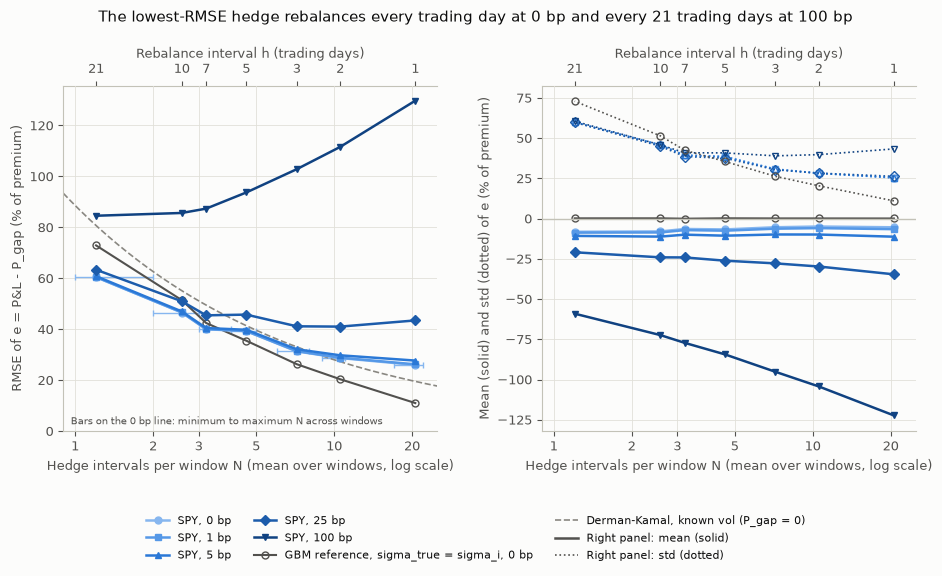

In [8]:
from matplotlib.lines import Line2D

mean_n = np.array([n_by_h[h].mean() for h in H_VALUES])
min_n = np.array([n_by_h[h].min() for h in H_VALUES])
max_n = np.array([n_by_h[h].max() for h in H_VALUES])
n_curve = np.geomspace(0.9, 25, 200)


def every(h):
    """'every trading day' or 'every h trading days'."""
    return "every trading day" if h == 1 else f"every {h} trading days"


fig, (ax_rmse, ax_ms) = plt.subplots(1, 2, figsize=(11, 5.4))
for c, colour, marker in zip(C_BP, COST_COLOURS, COST_MARKERS):
    stats = table_4a.xs(c, level="c (bp)")
    ax_rmse.errorbar(
        mean_n, stats["RMSE e (%)"], xerr=[mean_n - min_n, max_n - mean_n] if c == 0 else None,
        color=colour, marker=marker, lw=1.8, capsize=2, elinewidth=1,
    )
    ax_ms.plot(mean_n, stats["mean e (%)"], color=colour, marker=marker, lw=1.8)
    ax_ms.plot(mean_n, stats["std e (%)"], color=colour, marker=marker, lw=1.2, ls=":", mfc="none")
ax_rmse.plot(mean_n, reference["rmse"], color=INK_2, marker="o", mfc="none", lw=1.5)
ax_rmse.plot(n_curve, 100 * dk_scale * np.sqrt(np.pi / 4) / np.sqrt(n_curve), color=MUTED, ls="--", lw=1.2)
ax_rmse.text(0.02, 0.02, "Bars on the 0 bp line: minimum to maximum N across windows",
             transform=ax_rmse.transAxes, fontsize=7.5, color=INK_2)
ax_ms.plot(mean_n, reference["mean"], color=INK_2, marker="o", mfc="none", lw=1.5)
ax_ms.plot(mean_n, reference["std"], color=INK_2, marker="o", mfc="none", lw=1.2, ls=":")
ax_ms.axhline(0, color=AXIS, lw=1)
for ax in (ax_rmse, ax_ms):
    ax.set_xscale("log")
    ax.set_xlim(0.9, 25)
    ax.xaxis.set_major_locator(FixedLocator([1, 2, 3, 5, 10, 20]))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xlabel("Hedge intervals per window N (mean over windows, log scale)")
    top = ax.secondary_xaxis("top")
    top.set_xticks(mean_n, labels=[str(h) for h in H_VALUES])
    top.xaxis.set_minor_locator(NullLocator())
    top.set_xlabel("Rebalance interval h (trading days)")
ax_rmse.set_ylabel("RMSE of e = P&L - P_gap (% of premium)")
ax_ms.set_ylabel("Mean (solid) and std (dotted) of e (% of premium)")
ax_rmse.set_ylim(bottom=0)

handles = [
    Line2D([], [], color=colour, marker=marker, lw=1.8, label=f"SPY, {c} bp")
    for c, colour, marker in zip(C_BP, COST_COLOURS, COST_MARKERS)
] + [
    Line2D([], [], color=INK_2, marker="o", mfc="none", lw=1.5, label="GBM reference, sigma_true = sigma_i, 0 bp"),
    Line2D([], [], color=MUTED, ls="--", lw=1.2, label="Derman-Kamal, known vol (P_gap = 0)"),
    Line2D([], [], color=INK_2, lw=1.8, label="Right panel: mean (solid)"),
    Line2D([], [], color=INK_2, lw=1.2, ls=":", label="Right panel: std (dotted)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=8)
fig.subplots_adjust(bottom=0.24, wspace=0.28)
fig.suptitle(
    f"The lowest-RMSE hedge rebalances {every(best_h[0])} at 0 bp and {every(best_h[100])} at 100 bp",
    y=1.02,
)
save(fig, "fig8_hedging_error.png")
plt.show()

## Weekday diagnostic of P_step residuals
Under daily hedging without costs, each interval's hedged P&L minus its P_step term is grouped by the weekday of the interval's closing day. Monday intervals span the weekend: P_step charges three calendar days of sigma_i² there, against roughly one trading day of realised variance. Means are per interval in percent of premium, with 95% moving block bootstrap intervals from the full-sample resamples. η² is the share of residual variance that the weekday means explain.

In [9]:
weekday_table, eta2 = hg.weekday_diagnostic(
    base.interval_pnl, base.interval_p_step, dates, win.starts, win.ends, 1, boot_full
)
shown = weekday_table.copy()
for col in ["pnl", "p_step", "residual", "residual_lo", "residual_hi"]:
    shown[col] = 100 * shown[col]
shown = shown.rename(columns={
    "calendar_days": "mean calendar days", "pnl": "mean P&L (%)", "p_step": "mean P_step (%)",
    "residual": "mean residual (%)", "residual_lo": "residual lo (%)", "residual_hi": "residual hi (%)",
    "share": "share of total residual",
})
with pd.option_context("display.float_format", "{:.4f}".format):
    display(shown)
window_resid = base.pnl - base.p_step
print(f"eta^2, share of residual variance explained by weekday means: {eta2:.4f}")
print(f"Window residual P&L - P_step (h = 1, c = 0): mean {100 * window_resid.mean():+.3f}%, "
      f"std {100 * window_resid.std():.3f}% of premium")

,intervals,mean calendar days,mean P&L (%),mean P_step (%),mean residual (%),residual lo (%),residual hi (%),share of total residual
Monday,4410,3.0381,-4.3637,-4.2041,-0.1596,-0.2244,-0.0978,0.9534
Tuesday,5138,1.3025,-0.8988,-0.9054,0.0065,-0.0380,0.0435,-0.0453
Wednesday,5350,1.0037,-0.0226,-0.1017,0.0791,-0.0150,0.2054,-0.5731
Thursday,5222,1.0115,0.2656,0.3524,-0.0868,-0.2230,0.0031,0.6140
Friday,5233,1.0390,0.1775,0.1847,-0.0072,-0.1147,0.0857,0.0510
All,25353,1.4270,-0.8546,-0.8255,-0.0291,-0.0623,0.0019,1.0000


eta^2, share of residual variance explained by weekday means: 0.0038
Window residual P&L - P_step (h = 1, c = 0): mean -0.599%, std 5.725% of premium


## Textbook reference
The section 3 synthetic set (3,000 windows, 21 daily steps, sigma_true drawn around sigma_i) is computed here only as the textbook reference for the ladder. The headline compares real data with the real-calendar GBM benchmark in Table 4b.

In [10]:
textbook = {1: [], 5: []}
for seed_vols, seed_paths in SEEDS_TEXTBOOK:
    paths, times, sig = hg.synthetic_window_set(3000, seed_vols, seed_paths)
    for h in textbook:
        res = hg.simulate_window(paths, times, 0.0, sig, 100.0, h, 0.0)
        textbook[h].append([hg.r2_45(res.pnl, p) for p in (res.p_gap, res.p_path, res.p_step)])
textbook_median = {h: np.median(v, axis=0) for h, v in textbook.items()}
for h, m in textbook_median.items():
    print(
        f"Textbook reference only (section 3 set, median of {len(SEEDS_TEXTBOOK)} seed pairs), h = {h}: "
        f"R2_45 P_gap / P_path / P_step = {m[0]:.2f} / {m[1]:.2f} / {m[2]:.2f}"
    )

Textbook reference only (section 3 set, median of 40 seed pairs), h = 1: R2_45 P_gap / P_path / P_step = 0.76 / 0.93 / 0.98
Textbook reference only (section 3 set, median of 40 seed pairs), h = 5: R2_45 P_gap / P_path / P_step = 0.40 / 0.44 / 0.89


## Hedging headline numbers
Every number the hedging half of the headline needs, printed in one place.

In [11]:
def ladder_line(row):
    """R2_45 and slope of one ladder row, with bootstrap intervals when present."""
    if np.isnan(row.r2_lo):
        return f"R2_45 = {row.r2_45:.2f}, slope = {row.beta:.2f}"
    return (f"R2_45 = {row.r2_45:.2f} [{row.r2_lo:.2f}, {row.r2_hi:.2f}], "
            f"slope = {row.beta:.2f} [{row.beta_lo:.2f}, {row.beta_hi:.2f}], intercept = {100 * row.alpha:+.1f}%")


bench_1, ex_april_1 = ladders[("GBM benchmark", 1)], ladders[("Excluding April 2025", 1)]
print("=" * 100)
print("HEDGING HEADLINE NUMBERS")
print("P&L as % of the premium carried to expiry; daily hedging (h = 1) and no costs unless stated.")
print("=" * 100)
print(f"Sample: {win.starts.size} windows of 30 calendar days, starts {start_dates[0].date()} to "
      f"{start_dates[-1].date()}, {steps.min()} to {steps.max()} steps, mean N = {n_by_h[1].mean():.1f}")
print(f"Implied above realised (sigma_i^2*T0 > RV): {share_implied_above:.1%} of windows")
print(f"Mean VIX {win.sigma_i.mean():.1%}, mean realised vol {sigma_r.mean():.1%}")
print(f"Hedged P&L of the long call: mean {100 * base.pnl.mean():+.1f}%, std {100 * base.pnl.std():.1f}%")
print()
print("R2 ladder, real SPY windows [95% moving block bootstrap]:")
for name in PREDICTORS:
    print(f"  {name:<6} {ladder_line(ladder_1.loc[name])}")
print("GBM benchmark on the same calendars (sigma_true = realised vol, sigma_i = VIX, 100 paths per window):")
for name in PREDICTORS:
    print(f"  {name:<6} {ladder_line(bench_1.loc[name])}")
for h, m in textbook_median.items():
    print(f"Textbook reference only (section 3 synthetic set), h = {h}: "
          f"R2_45 = {m[0]:.2f} / {m[1]:.2f} / {m[2]:.2f} (P_gap / P_path / P_step)")
print()
print(f"Excluding April 2025 ({keep.sum()} windows):")
for name in PREDICTORS:
    print(f"  {name:<6} {ladder_line(ex_april_1.loc[name])}")
print(f"Non-overlapping subsamples ({N_OFFSETS} starting windows, {min(sizes)} to {max(sizes)} windows each):")
for name in PREDICTORS:
    row = table_4c.loc[(1, name)]
    print(f"  {name:<6} window 0: R2_45 = {row['R2_45 window 0']:.2f}, slope = {row['slope window 0']:.2f}; "
          f"across all: R2_45 median {row['R2_45 median']:.2f} ({row['R2_45 min']:.2f} to {row['R2_45 max']:.2f}), "
          f"slope median {row['slope median']:.2f} ({row['slope min']:.2f} to {row['slope max']:.2f})")
print()
rmse_1 = table_4a.xs(1, level="h")
print("Hedging error e = P&L - P_gap, daily: RMSE " + ", ".join(
    f"{rmse_1.loc[c, 'RMSE e (%)']:.1f}% at {c} bp" for c in C_BP))
print(f"GBM reference RMSE, daily, 0 bp: {reference.loc[1, 'rmse']:.1f}%")
print("Lowest-RMSE rebalance interval: " + ", ".join(f"h = {best_h[c]} at {c} bp" for c in C_BP))

HEDGING HEADLINE NUMBERS
P&L as % of the premium carried to expiry; daily hedging (h = 1) and no costs unless stated.
Sample: 1232 windows of 30 calendar days, starts 2021-10-01 to 2026-08-28, 17 to 22 steps, mean N = 20.6
Implied above realised (sigma_i^2*T0 > RV): 84.3% of windows
Mean VIX 19.2%, mean realised vol 15.8%
Hedged P&L of the long call: mean -17.6%, std 23.7%

R2 ladder, real SPY windows [95% moving block bootstrap]:
  P_gap  R2_45 = -0.20 [-1.12, 0.64], slope = 0.47 [0.39, 0.94], intercept = -11.8%
  P_path R2_45 = 0.67 [0.47, 0.85], slope = 0.72 [0.61, 1.02], intercept = -5.6%
  P_step R2_45 = 0.94 [0.92, 0.96], slope = 0.96 [0.91, 1.02], intercept = -1.3%
GBM benchmark on the same calendars (sigma_true = realised vol, sigma_i = VIX, 100 paths per window):
  P_gap  R2_45 = 0.57, slope = 0.72
  P_path R2_45 = 0.92, slope = 1.03
  P_step R2_45 = 0.96, slope = 0.99
Textbook reference only (section 3 synthetic set), h = 1: R2_45 = 0.76 / 0.93 / 0.98 (P_gap / P_path / P_step

The sensitivity run sets sigma_i to VIX minus the variance-swap gap. That gap comes from the Stage 4 surface, so the run and its Table 4 row are added in Stage 4.

## Stage 2b: Chain cleaning and implied forwards

Clean the option chain, fit parity forwards, and apply filters; produce Table 1.

## Stage 2c: Implied volatility extraction

Solve for implied vols via Brent's method; produce Figure 1.

## Stage 3: SVI calibration

Fit SVI smiles to each expiry slice; produce Figure 2 and Table 2.

## Stage 4: Arbitrage checks and variance-swap bridge

Check butterfly and calendar arbitrage, refit if needed, and build the variance-swap bridge; produce Figures 3 to 5 and Table 3.

## Stage 6: Write-up and reproducibility

Finalise README, verify fresh-install reproducibility, and tag v1.0.